# DP1 photo-z (RAIL)

In this tutorial, we will:
- access a photo-z catalog derived from Rubin’s Data Preview 1 using LSDB (for data rights holders)
- access the same catalog using pandas or any other Parquet reader (for all users)
- reconstruct the `qp.Ensemble` from the PDF nested columns

This notebook requires `qp`. Please install it using the following [instructions](https://qp.readthedocs.io/en/main/user_guide/installation.html).

## 1. Loading through LSDB

In order to access the catalog through LSDB, you must be a [Rubin data rights holder](https://rubinobservatory.org/for-scientists/data-products/data-policy), because the catalog includes sky coordinates and magnitudes from the original DP1 dataset. At present, there are two ways to access this data: RSP and CANFAR, described in [Accessing Rubin Data Preview 1 (DP1)](./rubin_dp1.ipynb).

In [1]:
from upath import UPath
import lsdb

base_path = UPath("/rubin/lsdb_data/dp1")
dp1_pz_catalog = lsdb.open_catalog(base_path / "object_photoz")
dp1_pz_catalog

,objectId,knn_z_median,knn_z_mean,knn_z_mode,knn_z_err95_low,knn_z_err95_high,knn_z_err68_low,knn_z_err68_high,tpz_z_median,tpz_z_mean,tpz_z_mode,tpz_z_err95_low,tpz_z_err95_high,tpz_z_err68_low,tpz_z_err68_high,cmnn_z_median,cmnn_z_mean,cmnn_z_mode,cmnn_z_err95_low,cmnn_z_err95_high,cmnn_z_err68_low,cmnn_z_err68_high,gpz_z_median,gpz_z_mean,gpz_z_mode,gpz_z_err95_low,gpz_z_err95_high,gpz_z_err68_low,gpz_z_err68_high,bpz_z_median,bpz_z_mean,bpz_z_mode,bpz_z_err95_low,bpz_z_err95_high,bpz_z_err68_low,bpz_z_err68_high,dnf_z_median,dnf_z_mean,dnf_z_mode,dnf_z_err95_low,dnf_z_err95_high,dnf_z_err68_low,dnf_z_err68_high,fzboost_z_median,fzboost_z_mean,fzboost_z_mode,fzboost_z_err95_low,fzboost_z_err95_high,fzboost_z_err68_low,fzboost_z_err68_high,lephare_z_median,lephare_z_mean,lephare_z_mode,lephare_z_err95_low,lephare_z_err95_high,lephare_z_err68_low,lephare_z_err68_high,bpz_ens_interp,cmnn_ens_norm,dnf_ens_interp,fzboost_ens_interp,knn_ens_mixmod,lephare_ens_interp,tpz_ens_interp,gpz_ens_norm,coord_ra,coord_dec
npartitions=5,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 3, Pixel: 2",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<xvals: [double], yvals: [double]>","nested<loc: [double], scale: [double]>","nested<xvals: [double], yvals: [double]>","nested<xvals: [double], yvals: [double]>","nested<means: [double], stds: [double], weight...","nested<xvals: [double], yvals: [double]>","nested<xvals: [double], yvals: [double]>","nested<loc: [double], scale: [double]>",double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 3, Pixel: 536",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 3, Pixel: 561",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## 2. Loading through single parquet

The photo-z parquet is available to everyone.

In [2]:
import nested_pandas as npd

dp1_pz_df = npd.read_parquet(
    "https://data.lsdb.io/hats/dp1/object_photoz.parquet", columns=["lephare_z_median", "knn_z_median"]
)
dp1_pz_df

,lephare_z_median,knn_z_median
0,0.379151,0.354946
1,0.847168,0.870491
...,...,...
544642,2.083531,1.607656
544643,0.564991,1.940476


### Plotting two estimators

Plotting, as an example, the results from Lephare and kNN.

Text(0, 0.5, 'kNN')

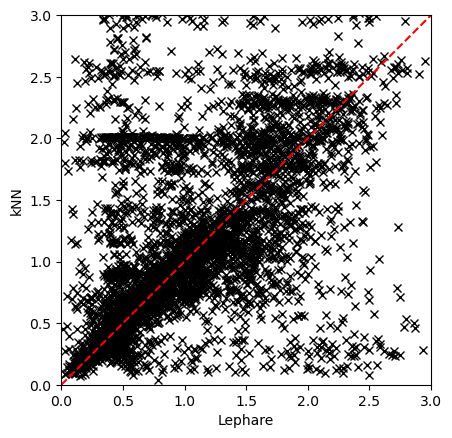

In [3]:
import matplotlib.pyplot as plt

plt.plot(dp1_pz_df["lephare_z_median"].iloc[::100], dp1_pz_df["knn_z_median"].iloc[::100], "x", color="black")
plt.gca().set_aspect("equal", adjustable="box")
plt.plot([0, 3], [0, 3], color="red", ls="--")
plt.xlim([0, 3])
plt.ylim([0, 3])
plt.xlabel("Lephare")
plt.ylabel("kNN")

## 3. Reconstructing a QP Ensemble

Here we demonstrate how to reconstruct a dictionary of `qp.Ensemble` objects from the HATS catalog.

Based on the column suffix (e.g., interp, mixmod, norm, hist, or quantile lengths like 99, 20, 5), we parse the nested data fields and rebuild each ensemble using the appropriate qp generator.

In [4]:
import qp
import numpy as np


def hats_to_qp(df):
    """Reconstruct `qp.Ensemble` objects from a partition."""
    ensembles = {}

    def extract(nf, subcol):
        return np.asarray([i[subcol] for i in nf])

    for col in df.nested_columns:
        nf = df[col]
        data_dict = {}
        ens_type = col.split("_")[-1]

        match ens_type:
            case "interp":
                data_dict["yvals"] = extract(nf, "yvals")
                data_dict["xvals"] = np.asarray(nf.iloc[-1]["xvals"])
                gen_class = qp.interp_gen
            case "mixmod":
                data_dict["means"] = extract(nf, "means")
                data_dict["stds"] = extract(nf, "stds")
                data_dict["weights"] = extract(nf, "weights")
                gen_class = qp.mixmod_gen
            case "norm":
                data_dict["loc"] = extract(nf, "loc")
                data_dict["scale"] = extract(nf, "scale")
                ensembles[col] = qp.Ensemble(qp.stats.norm, data=data_dict)
                gen_class = qp.stats.norm
            case "hist":
                data_dict["pdfs"] = extract(nf, "pdfs")
                data_dict["bins"] = np.linspace(0, 3, 301)
                gen_class = qp.hist_gen
            case "99" | "20" | "5":
                data_dict["locs"] = extract(nf, "locs")
                data_dict["quants"] = np.asarray(nf.iloc[-1]["quants"])
                gen_class = qp.quant_gen
            case _:
                continue

        ensembles[col] = qp.Ensemble(gen_class, data=data_dict)

    return ensembles

Notice that computing the `qp.Ensemble` is very computationally expensive. For demonstration purposes we only used a handful of objects.

In [5]:
hats_to_qp(dp1_pz_catalog.head())

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

{'bpz_ens_interp': Ensemble(the_class=interp,shape=(5, 301)),
 'cmnn_ens_norm': Ensemble(the_class=norm,shape=(5, 1)),
 'dnf_ens_interp': Ensemble(the_class=interp,shape=(5, 301)),
 'fzboost_ens_interp': Ensemble(the_class=interp,shape=(5, 301)),
 'knn_ens_mixmod': Ensemble(the_class=mixmod,shape=(5, 7)),
 'lephare_ens_interp': Ensemble(the_class=interp,shape=(5, 401)),
 'tpz_ens_interp': Ensemble(the_class=interp,shape=(5, 301)),
 'gpz_ens_norm': Ensemble(the_class=norm,shape=(5, 1))}

## About

**Authors**: Sandro Campos, Sarah Pelesky, Tianqing Zhang

**Last run**: Aug 27, 2026

If you use `lsdb` for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).